# Notebook 06 — Evaluasi Model & Analisis Distribusi Sentimen EWA

Penelitian : Aspect Category Sentiment Classification of EWA App Reviews Using IndoBERT
Fase CRISP-DM : Evaluation
Input : dataset_annotated_final.csv, predictions_svm_revisi.csv, predictions_indobert_revisi.csv, eval_*.csv, training_history_multiseed.json
Output : distribusi_aspek_final.png, distribusi_per_app_CI.png, proporsi_100stacked.png, kontekstualisasi_final.png, perbandingan_per_aspek.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Setup & Muat Data


In [1]:
# from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, json, matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/TA_ACSC_EWA"
ann = pd.read_csv(f"{BASE}/03_anotasi/data/dataset_annotated_final.csv")
print(f"Dataset final: {len(ann)} baris | {ann['review_id'].nunique()} ulasan unik")

pred_svm  = pd.read_csv(f"{BASE}/04_Modeling/tfidf_svm/predictions_svm_revisi.csv")
pred_bert = pd.read_csv(f"{BASE}/05_modeling/indobert/predictions_indobert_revisi.csv")
eval_svm  = pd.read_csv(f"{BASE}/04_Modeling/tfidf_svm/eval_svm_revisi.csv")
eval_bert = pd.read_csv(f"{BASE}/05_modeling/indobert/eval_indobert_revisi.csv")
hist      = json.load(open(f"{BASE}/05_modeling/indobert/training_history_multiseed.json"))
print(f"Prediksi test: SVM {len(pred_svm)} baris | IndoBERT {len(pred_bert)} baris")


Dataset final: 2266 baris | 2031 ulasan unik
Prediksi test: SVM 454 baris | IndoBERT 454 baris


## 2. Ringkasan Performa IndoBERT pada Test


In [2]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

labels = ['positif', 'negatif', 'netral']
macro_ckpt = f1_score(pred_bert['sentiment'], pred_bert['y_pred'], average='macro', labels=labels)
acc_ckpt   = accuracy_score(pred_bert['sentiment'], pred_bert['y_pred'])
tps        = hist['test_per_seed']

print('RINGKASAN PERFORMA INDOBERT (ACSC EWA)')
print('=' * 60)
print(f"  Model              : indobenchmark/indobert-base-p1")
print(f"  Pendekatan         : Sentence-Pair Classification")
print(f"  Test set           : {len(pred_bert)} baris (terkunci, bebas leakage)")
print()
print(f"  Test Macro-F1 per seed {hist['seeds']}:")
print(f"    {[round(x,4) for x in tps]}")
print(f"  KLAIM UTAMA (mean +/- std, 5 seed): {np.mean(tps):.4f} +/- {np.std(tps):.4f}")
print()
print(f"  Checkpoint perwakilan (seed 123): Macro-F1 {macro_ckpt:.4f} | Accuracy {acc_ckpt:.4f}")
print()
print(classification_report(pred_bert['sentiment'], pred_bert['y_pred'], labels=labels, digits=4))


RINGKASAN PERFORMA INDOBERT (ACSC EWA)
  Model              : indobenchmark/indobert-base-p1
  Pendekatan         : Sentence-Pair Classification
  Test set           : 454 baris (terkunci, bebas leakage)

  Test Macro-F1 per seed [42, 123, 2024, 7, 99]:
    [0.8782, 0.8843, 0.8865, 0.8493, 0.8825]
  KLAIM UTAMA (mean +/- std, 5 seed): 0.8762 +/- 0.0137

  Checkpoint perwakilan (seed 123): Macro-F1 0.8843 | Accuracy 0.9075

              precision    recall  f1-score   support

     positif     0.9489    0.9028    0.9253       247
     negatif     0.8711    0.9185    0.8942       184
      netral     0.8000    0.8696    0.8333        23

    accuracy                         0.9075       454
   macro avg     0.8734    0.8970    0.8843       454
weighted avg     0.9099    0.9075    0.9080       454


## 3. Distribusi Sentimen per Kategori Aspek


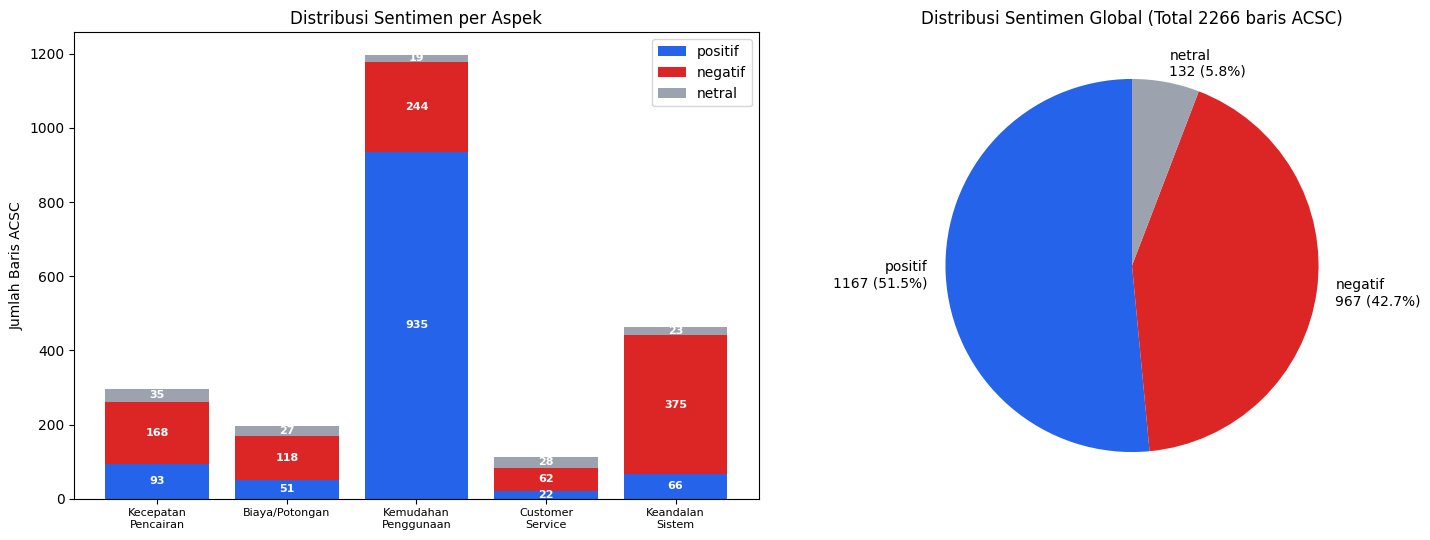

In [3]:
order = ['Kecepatan Pencairan','Biaya/Potongan','Kemudahan Penggunaan','Customer Service','Keandalan Sistem']
ct = pd.crosstab(ann['aspect_category'], ann['sentiment']).reindex(order)[['positif','negatif','netral']]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
colors = {'positif':'#2563eb','negatif':'#dc2626','netral':'#9ca3af'}
bottom = np.zeros(len(ct))
for s in ['positif','negatif','netral']:
    ax1.bar(range(len(ct)), ct[s], bottom=bottom, label=s, color=colors[s])
    for i, v in enumerate(ct[s]):
        if v > 0: ax1.text(i, bottom[i]+v/2, int(v), ha='center', va='center', color='white', fontweight='600', fontsize=8)
    bottom += ct[s].values
ax1.set_xticks(range(len(ct))); ax1.set_xticklabels([a.replace(' ','\n') for a in ct.index], fontsize=8)
ax1.set_ylabel('Jumlah Baris ACSC'); ax1.set_title('Distribusi Sentimen per Aspek'); ax1.legend()
tot = ann['sentiment'].value_counts()
ax2.pie(tot, labels=[f'{k}\n{v} ({v/len(ann)*100:.1f}%)' for k, v in tot.items()],
        colors=[colors[k] for k in tot.index], startangle=90)
ax2.set_title(f'Distribusi Sentimen Global (Total {len(ann)} baris ACSC)')
plt.tight_layout(); plt.savefig(f"{BASE}/06_evaluasi/distribusi_aspek_final.png", dpi=150, bbox_inches='tight'); plt.show()


## 4. Distribusi per Aplikasi + Margin of Error 95%

Ketidakpastian proporsi diukur dengan margin of error 1.96 x akar(p(1-p)/n). Aplikasi dengan jumlah ulasan kecil memiliki margin lebar sehingga perbandingannya dengan platform besar tidak setara secara statistik.


In [ ]:
def margin_error(k, n, z=1.96):
    if n == 0: return 0.0, 0.0
    p = k / n
    return p, z * np.sqrt(p * (1 - p) / n)

stat = []
for app, g in ann.groupby('app_name'):
    n = len(g); k = int((g['sentiment'] == 'positif').sum())
    p, m = margin_error(k, n)
    stat.append((app, n, p*100, m*100))
stat.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, s in enumerate(stat):
    c = '#dc2626' if s[1] < 100 else '#2563eb'
    ax.errorbar(s[2], i, xerr=[[min(s[3], s[2])], [min(s[3], 100-s[2])]],
                fmt='o', color='gray', ecolor=c, elinewidth=2.5, capsize=6, markersize=8)
    ax.annotate(f"{s[2]:.1f}% (+/-{s[3]:.1f}pp)", (s[2], i), xytext=(8, 0),
                textcoords='offset points', va='center', fontsize=9, fontweight='600')
ax.set_yticks(range(len(stat))); ax.set_yticklabels([f"{s[0]} (n={s[1]})" for s in stat])
ax.set_xlabel('% Sentimen Positif (baris ACSC) dengan margin of error 95%')
ax.set_title('Proporsi Sentimen Positif per Aplikasi\n(merah = n<100, margin lebar sehingga perbandingan tidak setara)')
ax.set_xlim(0, 105); ax.grid(axis='x', alpha=0.3); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(f"{BASE}/06_evaluasi/distribusi_per_app_CI.png", dpi=150, bbox_inches='tight'); plt.show()

print("Proporsi positif per aplikasi (margin of error 95%):")
for s in sorted(stat, key=lambda x: -x[2]):
    print(f"  {s[0]:<12}: {s[2]:5.1f}%  +/-{s[3]:.1f}pp  (n={s[1]})")


## 5. Proporsi Sentimen per Aspek (100% Stacked)


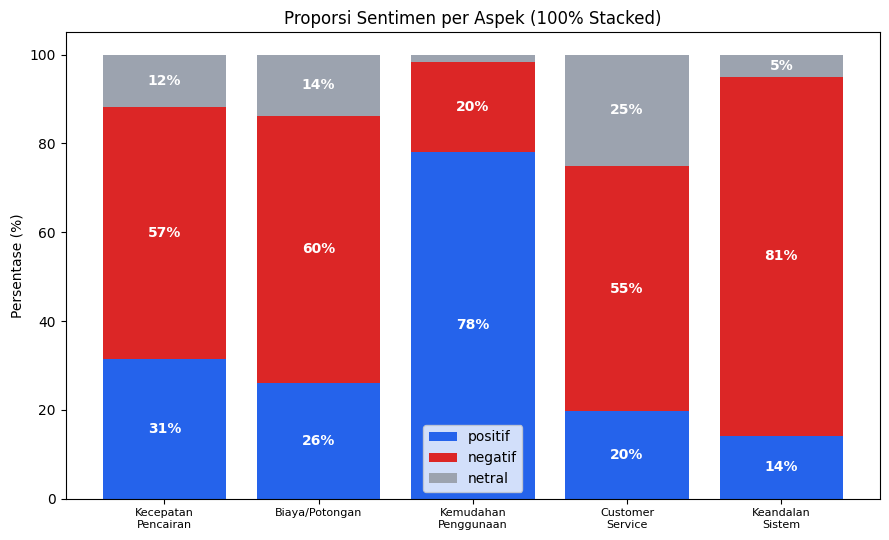

In [5]:
prop = (ct.T / ct.sum(axis=1)).T * 100
fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = np.zeros(len(prop))
for s in ['positif','negatif','netral']:
    ax.bar(range(len(prop)), prop[s], bottom=bottom, label=s,
           color={'positif':'#2563eb','negatif':'#dc2626','netral':'#9ca3af'}[s])
    for i, v in enumerate(prop[s]):
        if v > 4: ax.text(i, bottom[i]+v/2, f'{v:.0f}%', ha='center', va='center', color='white', fontweight='600')
    bottom += prop[s].values
ax.set_xticks(range(len(prop))); ax.set_xticklabels([a.replace(' ','\n') for a in prop.index], fontsize=8)
ax.set_ylabel('Persentase (%)'); ax.set_title('Proporsi Sentimen per Aspek (100% Stacked)'); ax.legend()
plt.tight_layout(); plt.savefig(f"{BASE}/06_evaluasi/proporsi_100stacked.png", dpi=150, bbox_inches='tight'); plt.show()


## 6. Kontekstualisasi IndoBERT terhadap Baseline

Baseline diposisikan sebagai lower-bound konvensional, bukan pembanding setara. Uplift dilaporkan dua lapis: terhadap klaim utama (rata-rata 5 seed) dan terhadap checkpoint perwakilan.


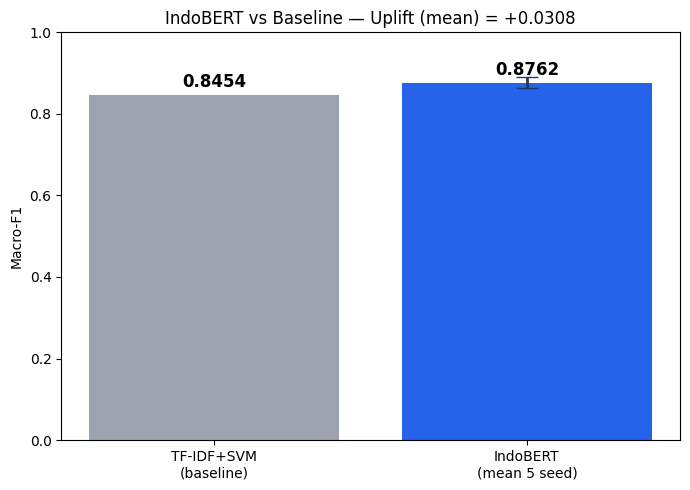

Baseline SVM                  : 0.8454
IndoBERT mean 5 seed          : 0.8762 +/- 0.0137
Uplift (mean)                 : +0.0308  (= 2.25 x std)
Uplift (checkpoint perwakilan): +0.0389
Seed terburuk (0.8493) tetap di atas baseline.


In [6]:
m_svm  = eval_svm['macro_f1'].iloc[0]
m_mean = float(np.mean(hist['test_per_seed'])); s_mean = float(np.std(hist['test_per_seed']))
m_ckpt = eval_bert['macro_f1'].iloc[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['TF-IDF+SVM\n(baseline)', 'IndoBERT\n(mean 5 seed)'], [m_svm, m_mean], color=['#9ca3af','#2563eb'])
ax.errorbar([1], [m_mean], yerr=[s_mean], fmt='none', ecolor='#1e3a5f', elinewidth=2, capsize=8)
for i, v in enumerate([m_svm, m_mean]):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='700', fontsize=12)
ax.set_ylabel('Macro-F1'); ax.set_ylim(0, 1.0)
ax.set_title(f'IndoBERT vs Baseline — Uplift (mean) = {m_mean - m_svm:+.4f}')
plt.tight_layout(); plt.savefig(f"{BASE}/06_evaluasi/kontekstualisasi_final.png", dpi=150, bbox_inches='tight'); plt.show()

print(f"Baseline SVM                  : {m_svm:.4f}")
print(f"IndoBERT mean 5 seed          : {m_mean:.4f} +/- {s_mean:.4f}")
print(f"Uplift (mean)                 : {m_mean - m_svm:+.4f}  (= {(m_mean-m_svm)/s_mean:.2f} x std)")
print(f"Uplift (checkpoint perwakilan): {m_ckpt - m_svm:+.4f}")
print(f"Seed terburuk ({min(hist['test_per_seed']):.4f}) tetap di atas baseline.")


In [ ]:
if eval_svm is not None and eval_bert is not None:
    m_svm=eval_svm['macro_f1'].iloc[0]; m_bert=eval_bert['macro_f1'].iloc[0]
    fig,ax=plt.subplots(figsize=(7,5))
    ax.bar(['TF-IDF+SVM\n(baseline/lower-bound)','IndoBERT\n(model utama)'],[m_svm,m_bert],
           color=['#9ca3af','#2563eb'])
    for i,v in enumerate([m_svm,m_bert]): ax.text(i,v+0.01,f'{v:.4f}',ha='center',fontweight='700',fontsize=12)
    ax.set_ylabel('Macro-F1'); ax.set_ylim(0,1.0)
    ax.set_title(f'IndoBERT vs Baseline SVM — Uplift = {m_bert-m_svm:+.4f}\n(SVM sebagai lower-bound konvensional)')
    plt.tight_layout(); plt.savefig(f"{BASE}/06_evaluasi/kontekstualisasi_final.png",dpi=150,bbox_inches='tight'); plt.show()
    print(f"Uplift IndoBERT atas baseline: {m_bert-m_svm:+.4f}")
else:
    print("Jalankan NB04 & NB05 dulu untuk memuat eval.")


## 7. Perbandingan Per-Aspek: IndoBERT vs SVM


In [7]:
from sklearn.metrics import f1_score
def per_aspek(dfp):
    rows = []
    for asp in order:
        d = dfp[dfp['aspect_category'] == asp]
        if len(d) == 0: continue
        f1s = [f1_score(d['sentiment'], d['y_pred'], average=None, labels=[c], zero_division=0)[0]
               for c in ['positif','negatif','netral']]
        rows.append({'Aspek': asp, 'n_test': len(d), 'Macro-F1': round(np.mean(f1s), 3)})
    return pd.DataFrame(rows)

a = per_aspek(pred_bert).rename(columns={'Macro-F1':'IndoBERT'})
b = per_aspek(pred_svm).rename(columns={'Macro-F1':'SVM'})[['Aspek','SVM']]
tbl = a.merge(b, on='Aspek'); tbl['Selisih'] = (tbl['IndoBERT'] - tbl['SVM']).round(3)
print(tbl.to_string(index=False))
tbl.to_csv(f"{BASE}/06_evaluasi/perbandingan_per_aspek.csv", index=False)
print("\nIndoBERT unggul pada aspek yang bergantung konteks (Customer Service, Kecepatan Pencairan);")
print("pada aspek berdistribusi ekstrem (Keandalan Sistem, 81% negatif) baseline sedikit unggul.")


               Aspek  n_test  IndoBERT   SVM  Selisih
 Kecepatan Pencairan      55     0.787 0.721    0.066
      Biaya/Potongan      42     0.800 0.806   -0.006
Kemudahan Penggunaan     256     0.940 0.912    0.028
    Customer Service      18     0.827 0.725    0.102
    Keandalan Sistem      83     0.694 0.733   -0.039

IndoBERT unggul pada aspek yang bergantung konteks (Customer Service, Kecepatan Pencairan);
pada aspek berdistribusi ekstrem (Keandalan Sistem, 81% negatif) baseline sedikit unggul.


## 8. Insight & Temuan Utama


In [8]:
print('INSIGHT & TEMUAN UTAMA — ANALISIS SENTIMEN EWA')
print('=' * 60)
neg_ratio = {}
for asp in order:
    sub = ann[ann['aspect_category'] == asp]
    neg_ratio[asp] = (sub['sentiment'] == 'negatif').sum() / len(sub)
most_neg = max(neg_ratio, key=neg_ratio.get)
most_pos_asp = max(order, key=lambda a_: (ann[ann['aspect_category']==a_]['sentiment']=='positif').mean())
pos_share = (ann[ann['aspect_category']==most_pos_asp]['sentiment']=='positif').mean()

print(f"[1] Aspek paling dikeluhkan  : {most_neg} ({neg_ratio[most_neg]*100:.0f}% negatif)")
print(f"[2] Aspek kekuatan utama     : {most_pos_asp} ({pos_share*100:.0f}% positif)")
app_pos = {app: (g['sentiment']=='positif').mean() for app, g in ann.groupby('app_name') if len(g) >= 100}
tinggi = max(app_pos, key=app_pos.get); rendah = min(app_pos, key=app_pos.get)
print(f"[3] Persepsi tertinggi (n>=100): {tinggi} ({app_pos[tinggi]*100:.1f}% positif)")
print(f"[4] Persepsi terendah  (n>=100): {rendah} ({app_pos[rendah]*100:.1f}% positif)")
print(f"[5] Prioritas perbaikan industri: keandalan sistem dan transparansi biaya;")
print(f"    kemudahan penggunaan adalah kekuatan yang perlu dipertahankan.")


INSIGHT & TEMUAN UTAMA — ANALISIS SENTIMEN EWA
[1] Aspek paling dikeluhkan  : Keandalan Sistem (81% negatif)
[2] Aspek kekuatan utama     : Kemudahan Penggunaan (78% positif)
[3] Persepsi tertinggi (n>=100): Paywatch (69.8% positif)
[4] Persepsi terendah  (n>=100): Wagely (38.4% positif)
[5] Prioritas perbaikan industri: keandalan sistem dan transparansi biaya;
    kemudahan penggunaan adalah kekuatan yang perlu dipertahankan.


## Ringkasan

Distribusi final 2.266 baris tersaji per aspek, per aplikasi (dengan margin of error 95%), dan proporsional. Kontekstualisasi menunjukkan IndoBERT (0,8762 plus-minus 0,0137) mengungguli baseline (0,8454) dengan uplift 0,0308, dan perbandingan per aspek memperlihatkan keunggulan terkonsentrasi pada aspek yang bergantung konteks. Seluruh gambar dan tabel tersimpan pada folder 06_evaluasi sebagai bahan Bab IV.
